# **Modern Porfolio Theory (Markowitz)**

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

## **1. Parameters and Data**

This section initializes the core parameters for the model, defining a specific universe of 10 major US stocks and establishing the analysis timeframe from 2018 to 2024 with a fixed risk-free rate of $3\%$. It retrieves historical daily closing prices using the `yfinance` library to compute the foundational inputs required for Markowitz optimization: the annualized expected returns vector and the annualized covariance matrix of the selected assets.

In [10]:
stocks = ["AAPL","MSFT","AMZN","GOOGL","META","NVDA","JPM","UNH","XOM","V"]

start_date = "2018-01-01"
end_date = "2024-01-01"
risk_free_rate = 0.03

np.random.seed(42)

data = yf.download(stocks, start=start_date, end=end_date)["Close"]
returns = data.pct_change().dropna()

mu = returns.mean() * 252
Sigma = returns.cov() * 252
n = len(stocks)

[*********************100%***********************]  10 of 10 completed


## **2. Portfolio Functions**

In this section, we establish the mathematical objective functions required by the optimization algorithm. It defines a helper function to calculate the expected return and volatility for any given set of asset weights, alongside a function that computes the negative Sharpe ratio (which the algorithm will minimize to find the maximum Sharpe ratio). It also strictly defines the boundaries for the optimizer, ensuring a fully invested, long-only portfolio where all weights must sit between 0 and 1 and collectively sum to exactly 1.

In [11]:
def portfolio_performance(weights):
    ret = np.dot(weights, mu)
    vol = np.sqrt(np.dot(weights.T, np.dot(Sigma, weights)))
    return ret, vol

def negative_sharpe(weights):
    ret, vol = portfolio_performance(weights)
    return -(ret - risk_free_rate) / vol

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0,1) for _ in range(n))
init_guess = np.ones(n)/n

## **3. Tangency Portfolio, Efficient Frontier and Capital Market Line**

This section executes the core Modern Portfolio Theory algorithms using SciPy's optimization suite (minimize with the SLSQP method). It first pinpoints the Tangency Portfolio, the optimal allocation that maximizes the risk-adjusted return (Sharpe ratio). Following this, it systematically calculates the Efficient Frontier by minimizing portfolio volatility across a continuous array of target returns, and derives the coordinates for the Capital Market Line (CML) to represent the new risk-return profile when factoring in the risk-free asset.

In [12]:
# Tangency Portfolio
opt = minimize(negative_sharpe, init_guess,
               method='SLSQP',
               bounds=bounds,
               constraints=constraints)

w_opt = opt.x
ret_opt, vol_opt = portfolio_performance(w_opt)
sharpe_opt = (ret_opt - risk_free_rate)/vol_opt

# Efficient Frontier
target_returns = np.linspace(mu.min(), mu.max(), 150)
efficient_vol = []

for target in target_returns:

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target}
    )

    res = minimize(lambda w: portfolio_performance(w)[1],
                   init_guess,
                   method='SLSQP',
                   bounds=bounds,
                   constraints=constraints)

    efficient_vol.append(res.fun)

efficient_vol = np.array(efficient_vol)

# CML
cml_x = np.linspace(0, efficient_vol.max()*1.1, 100)
cml_y = risk_free_rate + sharpe_opt * cml_x

## **4. Plot and Performance Metrics**

We plot the Efficient Frontier, the Capital Market Line, the risk-free rate, and the individual underlying assets on a standard risk-return plane, clearly highlighting the optimal Tangency Portfolio. Finally, it outputs a detailed quantitative summary, printing the exact capital allocation weights for each asset alongside the portfolio's expected annualized return, volatility, and Sharpe ratio.

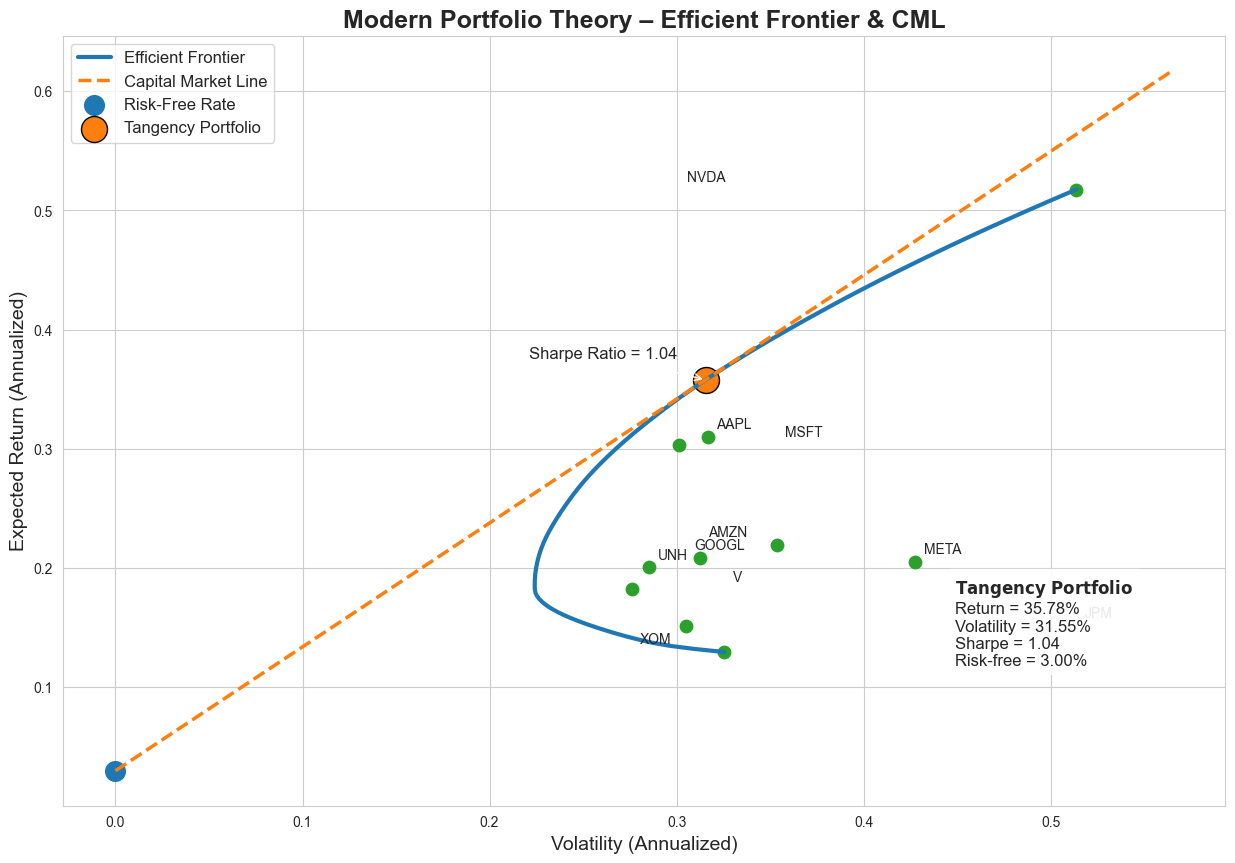

========== TANGENCY PORTFOLIO ==========

Weights:
AAPL: 0.2749
MSFT: 0.0000
AMZN: 0.0000
GOOGL: 0.0000
META: 0.0000
NVDA: 0.2357
JPM: 0.3247
UNH: 0.1647
XOM: 0.0000
V: 0.0000

Performance:
Expected Return: 35.7826%
Volatility: 31.5484%
Sharpe Ratio: 1.0391
Risk-Free Rate: 3.00%


In [13]:
sns.set_style("whitegrid")
plt.figure(figsize=(15,10))

plt.plot(efficient_vol, target_returns,
         linewidth=3, label="Efficient Frontier")

plt.plot(cml_x, cml_y,
         linestyle="--", linewidth=2.5,
         label="Capital Market Line")

plt.scatter(0, risk_free_rate, s=200,
            label="Risk-Free Rate")

plt.scatter(vol_opt, ret_opt,
            s=350, edgecolors='black',
            label="Tangency Portfolio")

asset_vol = np.sqrt(np.diag(Sigma))
asset_ret = mu  # keep as Series

plt.scatter(asset_vol, asset_ret, s=80)

for i, txt in enumerate(stocks):
    plt.annotate(txt, (asset_vol[i], asset_ret[txt]),
                 xytext=(6,6),
                 textcoords='offset points')


plt.annotate(f"Sharpe Ratio = {sharpe_opt:.2f}",
             xy=(vol_opt, ret_opt),
             xytext=(vol_opt*0.7, ret_opt*1.05),
             arrowprops=dict(arrowstyle="->"),
             fontsize=12)

textstr = '\n'.join((
    r'$\bf{Tangency\ Portfolio}$',
    f'Return = {ret_opt:.2%}',
    f'Volatility = {vol_opt:.2%}',
    f'Sharpe = {sharpe_opt:.2f}',
    f'Risk-free = {risk_free_rate:.2%}'
))

plt.gcf().text(0.72, 0.25, textstr,
               fontsize=12,
               bbox=dict(facecolor='white', alpha=0.9))

plt.title("Modern Portfolio Theory – Efficient Frontier & CML",
          fontsize=18, fontweight='bold')

plt.xlabel("Volatility (Annualized)", fontsize=14)
plt.ylabel("Expected Return (Annualized)", fontsize=14)

plt.legend(fontsize=12)
plt.show()

# Metrics
print("========== TANGENCY PORTFOLIO ==========")
print("\nWeights:")
for i in range(n):
    print(f"{stocks[i]}: {w_opt[i]:.4f}")

print("\nPerformance:")
print(f"Expected Return: {ret_opt:.4%}")
print(f"Volatility: {vol_opt:.4%}")
print(f"Sharpe Ratio: {sharpe_opt:.4f}")
print(f"Risk-Free Rate: {risk_free_rate:.2%}")